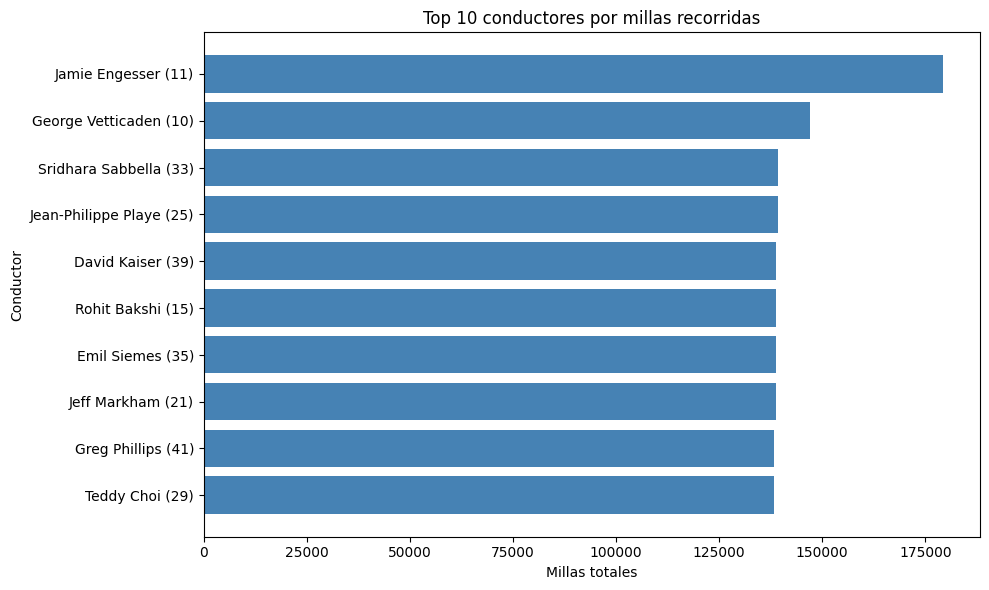

Archivos guardados en: c:\Users\jg702\Documents\GitHub\std-jennifer-gomez-sanchez\PRE_09_drivers_chatgpt\submission
 driverId                name  hours-logged  miles-logged
       11      Jamie Engesser          3642        179300
       10   George Vetticaden          3232        147150
       33   Sridhara Sabbella          2759        139285
       25 Jean-Philippe Playe          2723        139180
       39        David Kaiser          2745        138788
       15        Rohit Bakshi          2734        138750
       35         Emil Siemes          2728        138727
       21        Jeff Markham          2751        138719
       41       Greg Phillips          2723        138407
       29          Teddy Choi          2760        138255


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def main():
    # Encontrar la raíz de esta actividad.
    actual = Path.cwd()
    base = next(
        (
            carpeta
            for carpeta in (actual, actual.parent)
            if (carpeta / "data" / "drivers.csv").is_file()
        ),
        None,
    )

    if base is None:
        raise FileNotFoundError(
            f"No se encontró data/drivers.csv desde {actual}. "
            "Abre el notebook dentro de la actividad 09."
        )

    data = base / "data"

    archivo_timesheet = next(
        (
            data / nombre
            for nombre in ("timesheet.csv", "timesheets.csv")
            if (data / nombre).is_file()
        ),
        None,
    )

    if archivo_timesheet is None:
        raise FileNotFoundError(
            f"No se encontró timesheet.csv ni timesheets.csv en {data}"
        )

    # Leer los datos.
    drivers = pd.read_csv(data / "drivers.csv")
    timesheet = pd.read_csv(archivo_timesheet)

    # Sumar horas y millas por conductor.
    totals = (
        timesheet.groupby("driverId", as_index=False)
        .agg({
            "hours-logged": "sum",
            "miles-logged": "sum",
        })
    )

    # Incorporar los nombres.
    summary = totals.merge(
        drivers[["driverId", "name"]],
        on="driverId",
        how="left",
        validate="many_to_one",
    )

    summary = summary[
        ["driverId", "name", "hours-logged", "miles-logged"]
    ].sort_values(
        ["miles-logged", "driverId"],
        ascending=[False, True],
    )

    # Crear los archivos solicitados.
    submission = base / "submission"
    submission.mkdir(parents=True, exist_ok=True)
    summary.to_csv(submission / "summary.csv", index=False)

    top10 = summary.head(10).sort_values("miles-logged")
    labels = (
        top10["name"].fillna("Sin nombre")
        + " ("
        + top10["driverId"].astype(str)
        + ")"
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(labels, top10["miles-logged"], color="steelblue")
    ax.set_title("Top 10 conductores por millas recorridas")
    ax.set_xlabel("Millas totales")
    ax.set_ylabel("Conductor")
    fig.tight_layout()
    fig.savefig(submission / "top10_drivers.png", dpi=200)
    plt.show()
    plt.close(fig)

    print(f"Archivos guardados en: {submission}")
    print(summary.head(10).to_string(index=False))


main()